# ML Lab 3 — Decision Tree Classification

**Name:** Abdul Qudoos  
**Student ID:** 023-24-0233
**Section:** G  
**GitHub Profile:**(https://github.com/abdulqudoos181005)
**Kaggle Profile:** https://www.kaggle.com/abdulqudoos7860 
**Dataset:** Telco Customer Churn  
**Dataset Source:** Kaggle / cleaned dataset from Lab 2



## 1. Problem Definition

The goal is to predict whether a telecom customer will **churn (leave the company)** or stay. This can help the business identify customers who may leave and take action to retain them.

## 2. Dataset Verification

First, I load the cleaned dataset from Lab 2 and check its size, data types, and missing values.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nChurn counts:")
print(df["Churn"].value_counts())

Shape: (7043, 20)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   s

**Interpretation:** The dataset is checked before building the model. There should be no missing values left, and the Churn column shows the class balance.

## 3. Feature / Target Preparation

`Churn` is the target, so it is separated from the input features. I use one-hot encoding for categorical columns because they do not have a natural numerical order.

In [2]:
# Encode the target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Remove identifier column if it exists
id_cols = [col for col in ["customerID", "CustomerID", "customer_id"] if col in df.columns]
X = df.drop(columns=["Churn"] + id_cols)
y = df["Churn"]

# Convert categorical columns to numbers
X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nData types:")
print(X.dtypes)

print("\nMissing values in X:")
print(X.isnull().sum().sum())

X shape: (7043, 30)
y shape: (7043,)

Data types:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes    

**Why one-hot encoding?** It changes categories into separate 0/1 columns without pretending that one category is bigger or smaller than another.

## 4. Train / Test Split

I use an 80/20 split. `stratify=y` keeps the churn/non-churn ratio similar in both sets, which is useful because the target is not perfectly balanced.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 30)
X_test : (1409, 30)
y_train: (5634,)
y_test : (1409,)


## 5. Baseline Decision Tree

Now I train the first Decision Tree with default settings. Only `random_state` is fixed, as required by the manual.

In [4]:
from sklearn.tree import DecisionTreeClassifier

baseline = DecisionTreeClassifier(random_state=42)
baseline.fit(X_train, y_train)

train_pred = baseline.predict(X_train)
test_pred = baseline.predict(X_test)

print("Tree depth:", baseline.get_depth())

Tree depth: 24


**Interpretation:** The depth tells us how many levels the tree grew to by itself. A very deep tree can become too specific to the training data.

## 6. Model Evaluation

I evaluate the test set using accuracy, precision, recall, F1-score, and a confusion matrix instead of relying only on accuracy.

In [5]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

metrics = {
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1-score": f1_score(y_test, test_pred, zero_division=0)
}

baseline_metrics = pd.DataFrame(
    {"Score": metrics}
).round(3)

baseline_metrics

,Score
Accuracy,0.742
Precision,0.514
Recall,0.495
F1-score,0.504


**Interpretation:** These four scores give a better picture of model performance. Recall is especially useful here because missing a customer who is actually going to churn can matter to the business.

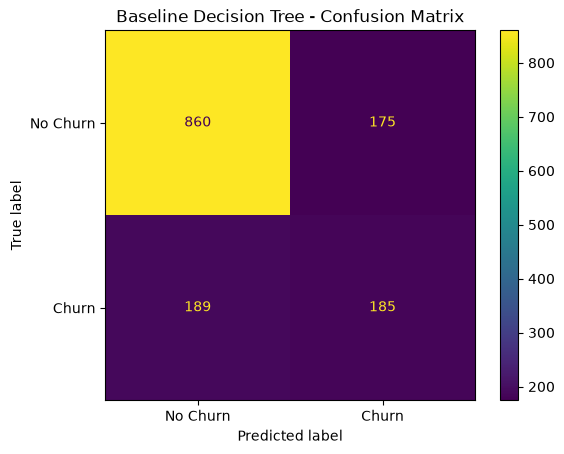

Actual churners correctly caught (TP): 185
Actual churners missed (FN): 189


In [6]:
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)
disp.plot()
plt.title("Baseline Decision Tree - Confusion Matrix")
plt.show()

print("Actual churners correctly caught (TP):", cm[1, 1])
print("Actual churners missed (FN):", cm[1, 0])

**Interpretation:** The bottom-right value is the number of churners correctly identified. The bottom-left value is the number of actual churners that the model missed.

## 7. Overfitting Experiment

First, I compare training and test accuracy. A large difference can mean that the tree has learned the training data too closely.

In [7]:
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Training accuracy:", round(train_acc, 3))
print("Test accuracy    :", round(test_acc, 3))
print("Gap              :", round(train_acc - test_acc, 3))

Training accuracy: 0.998
Test accuracy    : 0.742
Gap              : 0.256


**Interpretation:** If training accuracy is much higher than test accuracy, the tree is likely overfitting. The model should perform reasonably well on both datasets.

In [8]:
depths = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    tr_acc = accuracy_score(y_train, model.predict(X_train))
    te_acc = accuracy_score(y_test, model.predict(X_test))

    results.append({
        "max_depth": "unrestricted" if depth is None else depth,
        "train_accuracy": tr_acc,
        "test_accuracy": te_acc
    })

depth_results = pd.DataFrame(results)
depth_results.round(3)

,max_depth,train_accuracy,test_accuracy
0,2,0.791,0.787
1,3,0.791,0.787
2,4,0.793,0.796
3,5,0.801,0.794
4,6,0.807,0.797
5,8,0.835,0.780
6,10,0.872,0.756
7,unrestricted,0.998,0.742


**Interpretation:** As the tree gets deeper, training accuracy normally increases. The useful depth is where test performance is strong without creating a large train-test gap.

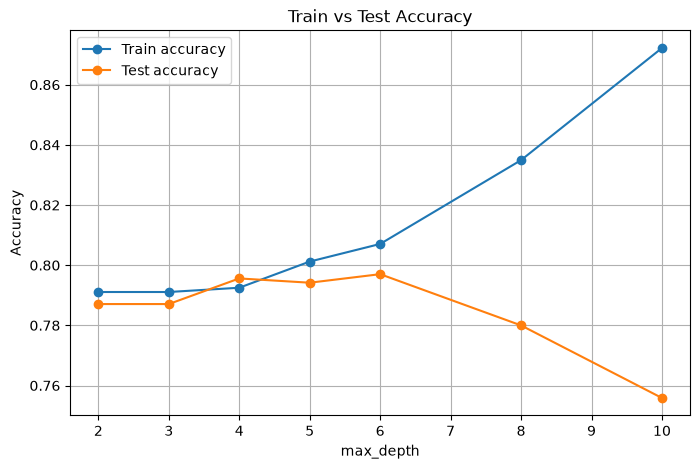

In [9]:
plot_depths = [2, 3, 4, 5, 6, 8, 10]
plot_results = depth_results.iloc[:7]

plt.figure(figsize=(8, 5))
plt.plot(plot_depths, plot_results["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(plot_depths, plot_results["test_accuracy"], marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Interpretation:** Overfitting starts to become noticeable when training accuracy keeps rising while test accuracy stops improving or starts falling. The exact depth should be taken from the results above.

## 8. Model Comparison

I select the depth using test performance together with the train-test gap, rather than simply choosing the highest training accuracy.

In [10]:
# Choose the depth with the best test accuracy.
# If several depths tie, prefer the smaller tree.
temp = depth_results.copy()
temp["depth_num"] = temp["max_depth"].apply(
    lambda x: 999 if x == "unrestricted" else x
)

best_row = temp.sort_values(
    ["test_accuracy", "depth_num"],
    ascending=[False, True]
).iloc[0]

best_depth = None if best_row["max_depth"] == "unrestricted" else int(best_row["max_depth"])

print("Chosen max_depth:", best_depth)
print("Test accuracy:", round(best_row["test_accuracy"], 3))
print("Reason: this depth gives strong test performance without unnecessarily using a very deep tree.")

Chosen max_depth: 6
Test accuracy: 0.797
Reason: this depth gives strong test performance without unnecessarily using a very deep tree.


In [11]:
chosen_model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)
chosen_model.fit(X_train, y_train)

chosen_pred = chosen_model.predict(X_test)

chosen_metrics = {
    "Accuracy": accuracy_score(y_test, chosen_pred),
    "Precision": precision_score(y_test, chosen_pred, zero_division=0),
    "Recall": recall_score(y_test, chosen_pred, zero_division=0),
    "F1-score": f1_score(y_test, chosen_pred, zero_division=0)
}

comparison = pd.DataFrame({
    "Baseline": metrics,
    "Chosen Model": chosen_metrics
}).round(3)

comparison

,Baseline,Chosen Model
Accuracy,0.742,0.797
Precision,0.514,0.675
Recall,0.495,0.455
F1-score,0.504,0.543


**Interpretation:** The chosen model is compared with the baseline using all four required metrics. A slightly lower accuracy can still be acceptable if recall, F1-score, and generalization are better balanced.

### Entropy Model

The manual also asks for a tree using `entropy` instead of the default `gini` criterion.

In [12]:
entropy_model = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion="entropy",
    random_state=42
)
entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

entropy_metrics = {
    "Accuracy": accuracy_score(y_test, entropy_pred),
    "Precision": precision_score(y_test, entropy_pred, zero_division=0),
    "Recall": recall_score(y_test, entropy_pred, zero_division=0),
    "F1-score": f1_score(y_test, entropy_pred, zero_division=0)
}

comparison_all = pd.DataFrame({
    "Baseline (Gini)": metrics,
    "Chosen (Gini)": chosen_metrics,
    "Entropy": entropy_metrics
}).round(3)

comparison_all

,Baseline (Gini),Chosen (Gini),Entropy
Accuracy,0.742,0.797,0.794
Precision,0.514,0.675,0.619
Recall,0.495,0.455,0.583
F1-score,0.504,0.543,0.601


**Interpretation:** Entropy and Gini are two ways of choosing the best split. The better model here is the one that gives the most useful balance of test performance, especially recall and F1-score.

## 9. Feature Importance

Feature importance shows which input columns contributed most to the chosen tree's decisions.

Top 5 features:
tenure                            0.3901
InternetService_Fiber optic       0.3277
TotalCharges                      0.0594
PaymentMethod_Electronic check    0.0345
MonthlyCharges                    0.0330
dtype: float64


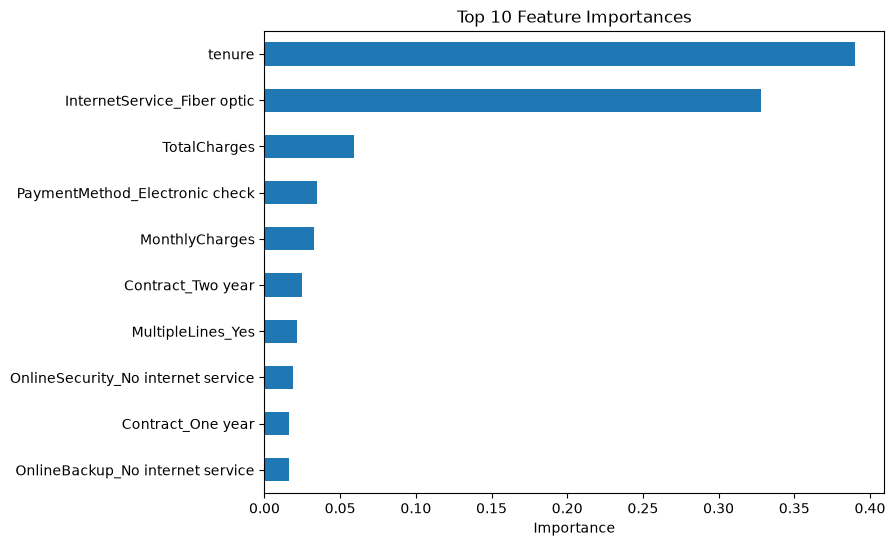

In [13]:
importance = pd.Series(
    chosen_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 5 features:")
print(importance.head(5).round(4))

plt.figure(figsize=(8, 6))
importance.head(10).sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()

**Interpretation:** The top features are the ones the tree relied on most when making its decisions. Compare these features with the important patterns found during Lab 2 EDA.

## 10. Interpretation

The feature-importance results should be checked against the earlier EDA. If important features here were also related to churn in Lab 2, the model supports those earlier observations. If they differ, the tree may be finding a pattern that was less obvious during EDA.

## 11. Conclusion

The final model should be judged using test performance and the train-test gap rather than training accuracy alone. The depth-limited tree helps control overfitting while keeping useful predictive performance. Precision, recall, and F1-score give more information than accuracy alone because churn is not perfectly balanced. A main limitation is that a single Decision Tree can still be sensitive to the data and may not generalize as well as stronger ensemble methods. With more time, I would try another algorithm, improve the features, and investigate ways to handle class imbalance.

## 12. ID3 From Scratch — Play Badminton

This part is kept separate from scikit-learn because the manual specifically asks for ID3 without built-in decision-tree libraries.

The code below implements **entropy** and **information gain**, then prints the gain for each attribute at every split.

In [14]:
# Play Badminton dataset
play = pd.DataFrame({
    "Outlook": ["Sunny","Sunny","Overcast","Rain","Rain","Rain","Overcast",
                "Sunny","Sunny","Rain","Sunny","Overcast","Overcast","Rain"],
    "Temperature": ["Hot","Hot","Hot","Mild","Cool","Cool","Cool",
                    "Mild","Cool","Mild","Mild","Mild","Hot","Mild"],
    "Humidity": ["High","High","High","High","Normal","Normal","Normal",
                 "High","Normal","Normal","Normal","High","Normal","High"],
    "Wind": ["Weak","Strong","Weak","Weak","Weak","Strong","Strong",
             "Weak","Weak","Weak","Strong","Strong","Weak","Strong"],
    "Play": ["No","No","Yes","Yes","Yes","No","Yes",
             "No","Yes","Yes","Yes","Yes","Yes","No"]
})

play

,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [15]:
def entropy(y):
    counts = y.value_counts()
    probs = counts / len(y)
    return -(probs * np.log2(probs)).sum()

def information_gain(df, attribute, target="Play"):
    total_entropy = entropy(df[target])
    weighted_entropy = 0

    for _, group in df.groupby(attribute):
        weighted_entropy += (len(group) / len(df)) * entropy(group[target])

    return total_entropy - weighted_entropy

def print_gains(df, target="Play"):
    attributes = [col for col in df.columns if col != target]

    for attr in attributes:
        print(attr, ":", round(information_gain(df, attr, target), 4))

print("Information gain at the first split:")
print_gains(play)

Information gain at the first split:
Outlook : 0.2467
Temperature : 0.0292
Humidity : 0.1518
Wind : 0.0481


In [16]:
def id3(df, target="Play", level=0):
    attributes = [col for col in df.columns if col != target]

    # Stop if all rows have the same target
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]

    # Stop if there are no attributes left
    if not attributes:
        return df[target].mode()[0]

    gains = {attr: information_gain(df, attr, target) for attr in attributes}

    print("  " * level + "Gains:")
    for attr, gain in gains.items():
        print("  " * level + f"{attr}: {gain:.4f}")

    best_attr = max(gains, key=gains.get)
    print("  " * level + "Best split:", best_attr)

    tree = {best_attr: {}}

    for value, group in df.groupby(best_attr):
        remaining = group.drop(columns=[best_attr])
        tree[best_attr][value] = id3(remaining, target, level + 1)

    return tree

print("ID3 tree and gain values:")
tree = id3(play)
print("\nFinal tree:")
print(tree)

ID3 tree and gain values:
Gains:
Outlook: 0.2467
Temperature: 0.0292
Humidity: 0.1518
Wind: 0.0481
Best split: Outlook
  Gains:
  Temperature: 0.0200
  Humidity: 0.0200
  Wind: 0.9710
  Best split: Wind
  Gains:
  Temperature: 0.5710
  Humidity: 0.9710
  Wind: 0.0200
  Best split: Humidity

Final tree:
{'Outlook': {'Overcast': 'Yes', 'Rain': {'Wind': {'Strong': 'No', 'Weak': 'Yes'}}, 'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}}}


**Interpretation:** ID3 chooses the attribute with the highest information gain at each split. The printed gain values show why each split was selected.